# Testing the Effectiveness of a Campaign on Questionnaire Responsiveness

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [2]:
# Upoad data
df = pd.read_csv("AdSmartABdata - AdSmartABdata.csv")

# Preliminary analysis

In [3]:
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [4]:
df.describe()

,hour,platform_os,yes,no
count,8077.000000,8077.000000,8077.000000,8077.000000
mean,11.615080,5.947134,0.070818,0.083075
std,5.734879,0.224333,0.256537,0.276013
min,0.000000,5.000000,0.000000,0.000000
25%,7.000000,6.000000,0.000000,0.000000
50%,13.000000,6.000000,0.000000,0.000000
75%,15.000000,6.000000,0.000000,0.000000
max,23.000000,7.000000,1.000000,1.000000


In [5]:
# Missing data
df[df.isnull().any(axis=1)]

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no


In [6]:
# Coarsen multi-category data 
df['device_make'] = df['device_make'].str.split().str[0]

In [7]:
df['time_of_day'] = pd.cut(df['hour'],
    bins=[0,6,12,18,24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=False
)

# Balanced data check

## Group sizes

In [8]:
df['experiment'].value_counts()

experiment
control    4071
exposed    4006
Name: count, dtype: int64

## Resposes over time

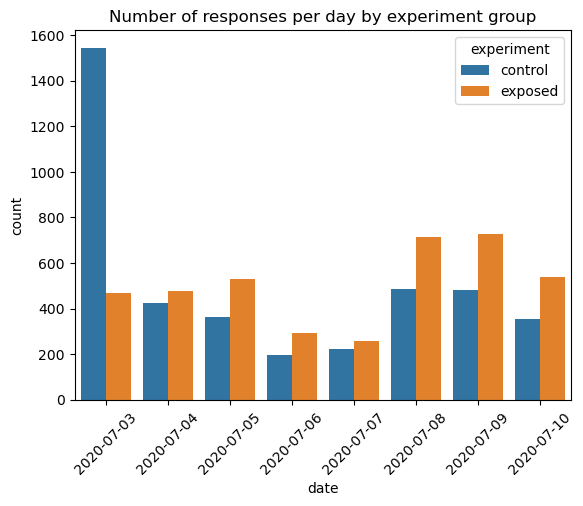

In [9]:
daily_counts = df.groupby(['date', 'experiment']).size().reset_index(name='count')
sns.barplot(daily_counts, x='date', y='count', hue = 'experiment')
plt.title("Number of responses per day by experiment group")
plt.xticks(rotation = 45)
plt.show()

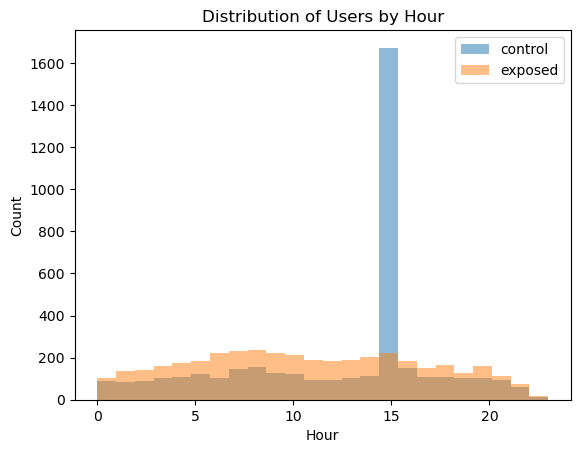

In [10]:
df.groupby('experiment')['hour'].value_counts(normalize=True)['control']
plt.hist(df[df['experiment'] == 'control']['hour'], bins=24, alpha=0.5, label='control')
plt.hist(df[df['experiment'] == 'exposed']['hour'], bins=24, alpha=0.5, label='exposed')
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title('Distribution of Users by Hour')
plt.legend()
plt.show()

In [11]:
contingency = pd.crosstab(df['yes'], df['date'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")

Chi² = 6.629, p-value = 4.6853e-01


In [12]:
contingency = pd.crosstab(df['yes'], df['hour'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")

Chi² = 23.505, p-value = 4.3162e-01


Both date and a time of the day seem to impact the assignments to the groups. The strongly unbalanced day (2020-07-03) and hour (3 p.m.) do not, however; invalidate A/B test.

## Browsers used across the groups

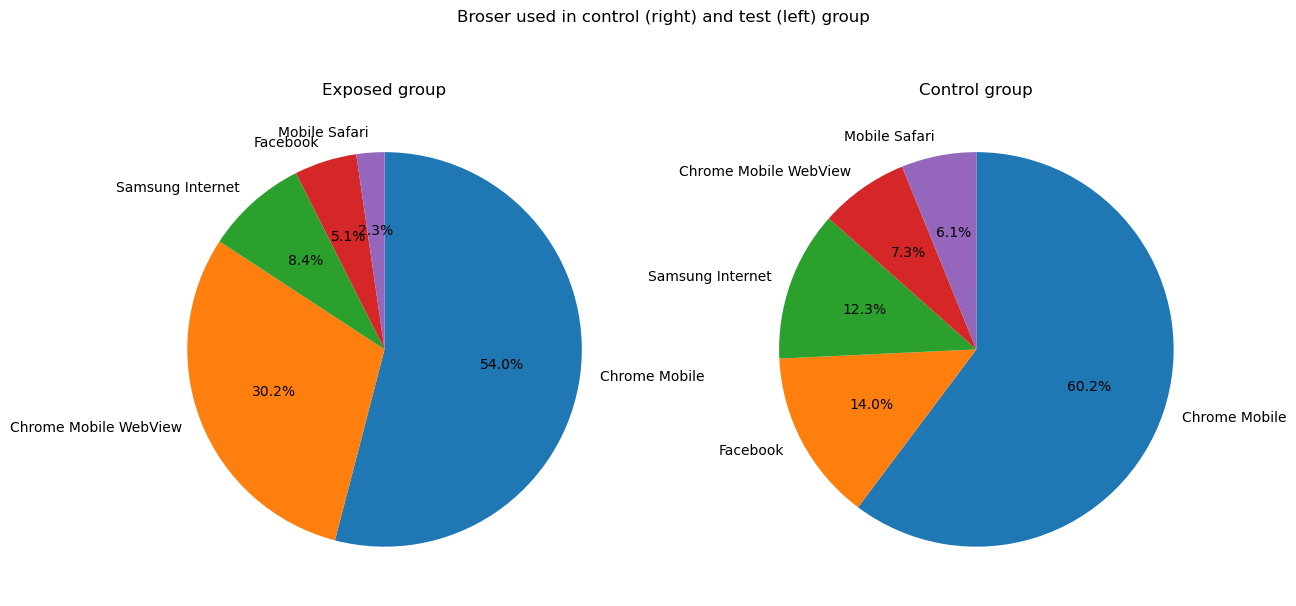

In [13]:
# Dummy Variable for 'experiment'
df['dummy_experiment'] = np.where(df['experiment'] == 'exposed', 1, 0)
# Control

exposed = df[df['dummy_experiment'] ==1].copy()
exposed_browser_types_c = exposed['browser'].value_counts().nlargest(5)
control = df[df['dummy_experiment'] ==0].copy()
colntrol_browser_types_c = control['browser'].value_counts().nlargest(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))
fig.suptitle('Broser used in control (right) and test (left) group')
ax1.pie(exposed_browser_types_c,
        labels=exposed_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
       )
ax1.set_title('Exposed group')
ax2.pie(colntrol_browser_types_c,
        labels=colntrol_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False)
ax2.set_title('Control group')
plt.show()

In [14]:
count_browsers = df.groupby('browser')['experiment'].value_counts().unstack(fill_value=0)

# Keep only browsers that appear in both groups
valid_browsers = count_browsers[(count_browsers['control'] > 0) & (count_browsers['exposed'] > 0)].index
df = df[df['browser'].isin(valid_browsers)].copy()

The groups are size-wise balanced.
The browsers used across the both groups are also roughly similar. 

## Correlation matrix

In [15]:
df['date_cat'] = pd.Categorical(df['date']).codes

In [16]:
df['date_cat'].unique()

array([7, 4, 2, 0, 6, 1, 3, 5], dtype=int8)

In [17]:
corr_marix = df[['dummy_experiment','hour','platform_os', 'date_cat']].corr()
corr_marix

,dummy_experiment,hour,platform_os,date_cat
dummy_experiment,1.000000,-0.155424,0.101561,0.238918
hour,-0.155424,1.000000,0.000321,-0.086734
platform_os,0.101561,0.000321,1.000000,0.008352
date_cat,0.238918,-0.086734,0.008352,1.000000


In [18]:
df.groupby(['experiment'])['platform_os'].value_counts()

experiment  platform_os
control     6              3761
            5               307
exposed     6              3881
            5               120
Name: count, dtype: int64

In [19]:
# Remove the single record with platform os 7 that violates positivity assumption
df = df[df['platform_os'] != 7]

The assignment to the groups seems biased with respect to the platform_os. Most exposed users are on platform 6 (97%),
while control users are slightly more mixed (only 92% on platform 6, and 7.5% on platform 5).

# Hypothesis
H0: mu_0 >= mu_1

H1: mu_0 < mu_1

Assuming randomners at the group assignment, this hypotheseis specifies one-sided alternative hypothesis, which tests that the mean number of 'yes' responses is greater in the exposed group than in the control group. The outcome is binary (yes/no), so we are comparing the conversion rates between two independent groups. Because both groups contain over 4,000 observations, the sampling distribution of the sample proportion is approximately normal by the Central Limit Theorem. Therefore, a two-sample t-test (or equivalently, a two-proportion z-test for large samples) can be used to test whether the conversion rates differ between the groups.

In [20]:
from statsmodels.stats.proportion import proportions_ztest

# Number of successes ("yes")
successes = [
    df[df["experiment"] == "exposed"]["yes"].sum(),
    df[df["experiment"] == "control"]["yes"].sum()
]

# Number of users
nobs = [
    len(df[df["experiment"] == "exposed"]),
    len(df[df["experiment"] == "control"])
]

z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=nobs,
    alternative="larger"   # exposed > control
)

print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.4f}")

z = 2.115
p = 0.0172


The two-proportion z-test found that users exposed to the new advertisement converted at a significantly higher rate than users in the control group (z = 2.12, p = 0.017). This provides evidence that the new advertisement improves the probability of a user responding "yes."

# Causal Inference
The analysis of the imbalance in the assignment of users to different groups has show that random sapling has been compromised and it needs to be taken into account as a confounder. Additionaly other response predictors will be added to the model to improve its precision. Here we pose the question "What is the causal effect of showing the ad on the probability that a user says ‘yes’?"

## Estimate naive effect

In [21]:
# Unadjusted effect
unadjusted_effect = df[df['experiment']=='exposed']['yes'].mean() - df[df['experiment']=='control']['yes'].mean()
print(f' Without accounting for any other covariate, the exposed group had a {np.round(unadjusted_effect * 100, 2)} percentage point higher conversion rate than the control group')

 Without accounting for any other covariate, the exposed group had a 1.21 percentage point higher conversion rate than the control group


## Identification of possible confounders

In [22]:
print(pd.crosstab(df['date'], df['experiment'], normalize='index'))
print("Date is associated with treatment assignment.")
contingency = pd.crosstab(df['yes'], df['date'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")
print("Chi-square test suggests that date does not confound the effect of the experiment on yes.")

experiment   control   exposed
date                          
2020-07-03  0.766899  0.233101
2020-07-04  0.472284  0.527716
2020-07-05  0.406742  0.593258
2020-07-06  0.400000  0.600000
2020-07-07  0.464435  0.535565
2020-07-08  0.404344  0.595656
2020-07-09  0.397351  0.602649
2020-07-10  0.397982  0.602018
Date is associated with treatment assignment.
Chi² = 6.687, p-value = 4.6223e-01
Chi-square test suggests that date does not confound the effect of the experiment on yes.


In [23]:
print(pd.crosstab(df['device_make'], df['experiment'], normalize='index'))
print("If randomization worked perfectly, we'd expect roughly the same device_make proportions in the control and exposed groups. Device make is associated with treatment assignment.")
contingency = pd.crosstab(df['yes'], df['device_make'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")
print("Chi-square test and group assignment analysis suggest that device make confounds the effect of the experiment on yes.")

experiment    control   exposed
device_make                    
5008Y_EEA    1.000000  0.000000
5099Y        0.000000  1.000000
6039Y        0.000000  1.000000
A0001        0.500000  0.500000
ALE-L21      0.000000  1.000000
...               ...       ...
XT1580       0.000000  1.000000
XiaoMi       0.607143  0.392857
YAL-L21      0.333333  0.666667
iPhone       0.717593  0.282407
moto         0.400000  0.600000

[103 rows x 2 columns]
If randomization worked perfectly, we'd expect roughly the same device_make proportions in the control and exposed groups. Device make is associated with treatment assignment.
Chi² = 139.714, p-value = 7.8344e-03
Chi-square test and group assignment analysis suggest that device make confounds the effect of the experiment on yes.


In [24]:
print(pd.crosstab(df['browser'], df['experiment'], normalize='index'))
print("If randomization worked perfectly, we'd expect roughly the same browser proportions in the control and exposed groups. Browser is associated with treatment assignment.")
contingency = pd.crosstab(df['yes'], df['browser'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")
print("Chi-square test and group assignment analysis suggest that browser confounds the effect of the experiment on yes.")

experiment                   control   exposed
browser                                       
Chrome                      0.333333  0.666667
Chrome Mobile               0.529205  0.470795
Chrome Mobile WebView       0.196105  0.803895
Chrome Mobile iOS           0.666667  0.333333
Facebook                    0.734293  0.265707
Mobile Safari               0.729970  0.270030
Mobile Safari UI/WKWebView  0.681818  0.318182
Pinterest                   0.666667  0.333333
Samsung Internet            0.597087  0.402913
If randomization worked perfectly, we'd expect roughly the same browser proportions in the control and exposed groups. Browser is associated with treatment assignment.
Chi² = 33.691, p-value = 4.6215e-05
Chi-square test and group assignment analysis suggest that browser confounds the effect of the experiment on yes.


In [25]:
print(pd.crosstab(df['platform_os'], df['experiment'], normalize='index'))
print("Date is associated with treatment assignment.")
contingency = pd.crosstab(df['yes'], df['platform_os'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4e}")
print("The chi-square statistic was 23.03, indicating that the observed frequencies differed substantially from those expected under independence. This resulted in a highly significant p-value (p < 0.001), providing strong evidence that platform_os and conversion are associated.")

experiment    control   exposed
platform_os                    
5            0.718970  0.281030
6            0.492149  0.507851
Date is associated with treatment assignment.
Chi² = 23.034, p-value = 1.5915e-06
The chi-square statistic was 23.03, indicating that the observed frequencies differed substantially from those expected under independence. This resulted in a highly significant p-value (p < 0.001), providing strong evidence that platform_os and conversion are associated.


## Stratification

In [26]:
# Compute effect within each device_make group
hour_effects = df.groupby('device_make').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['device_make'].value_counts(normalize=True)
overall_effect = (hour_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")

Weighted average treatment effect: 0.01


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_83281/3333378875.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_effects = df.groupby('device_make').apply(


Because the adjusted effect is very close to the unadjusted effect, it suggests that device_make is not a strong confounder.

After comparing exposed and control users within the same hour groups, the estimated treatment effect is approximately 1 percentage point. Because the adjusted effect is very close to the unadjusted effect, it suggests that hour is not a strong confounder.

Weighted average treatment effect: 0.01


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_83281/2338483802.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  browser_effects = df.groupby('browser').apply(


<Axes: title={'center': 'Treatment effect by browser'}, xlabel='browser'>

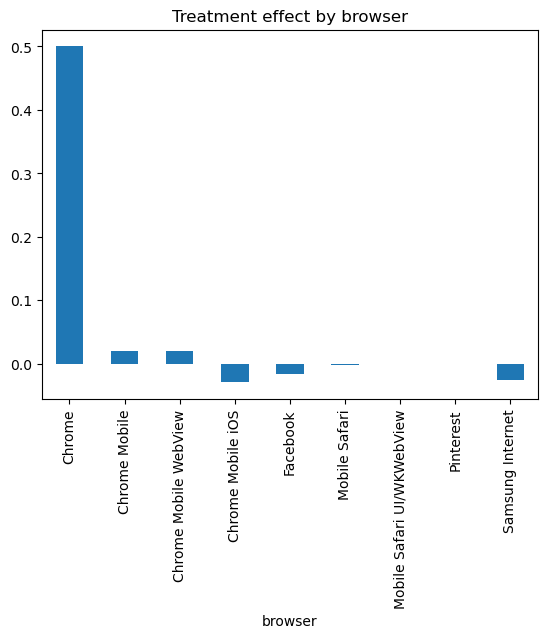

In [27]:
# Compute effect within each browser group
browser_effects = df.groupby('browser').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['browser'].value_counts(normalize=True)
overall_effect = (browser_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")
browser_effects.plot(kind='bar', title="Treatment effect by browser")

In [28]:
df['browser'].value_counts()

browser
Chrome Mobile                 4554
Chrome Mobile WebView         1489
Samsung Internet               824
Facebook                       764
Mobile Safari                  337
Chrome Mobile iOS               51
Mobile Safari UI/WKWebView      44
Chrome                           3
Pinterest                        3
Name: count, dtype: int64

In [29]:
browser_counts = df['browser'].value_counts()

rare_browsers = browser_counts[browser_counts < 50].index

df['browser_clean'] = df['browser'].replace(
    rare_browsers,
    'Other'
)

Because the adjusted effect is very close to the unadjusted effect, it suggests that browser is not a strong confounder.

Weighted average treatment effect: 0.01


/var/folders/l1/6jvqsq8s0lz9m8sm4f3sfkbr0000gn/T/ipykernel_83281/1139584053.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  date_effects = df.groupby('platform_os').apply(


<Axes: title={'center': 'Treatment effect by date'}, xlabel='platform_os'>

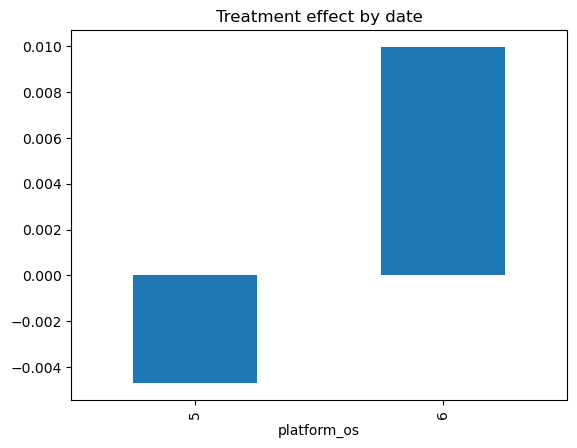

In [30]:
# Compute effect within each platform group
date_effects = df.groupby('platform_os').apply(
    lambda g: g.loc[g['dummy_experiment']==1, 'yes'].mean() - 
              g.loc[g['dummy_experiment']==0, 'yes'].mean()
)

# Weight by stratum size
weights = df['platform_os'].value_counts(normalize=True)
overall_effect = (date_effects * weights).sum()

print(f"Weighted average treatment effect: {overall_effect:.2f}")
date_effects.plot(kind='bar', title="Treatment effect by date")

Because the adjusted effect is very close to the unadjusted effect, it suggests that platform_os is not a strong confounder.

## Causal inference

In [31]:
base_model = smf.logit('yes ~ C(experiment)', data = df).fit()
base_model.summary()

Optimization terminated successfully.
         Current function value: 0.255654
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8067
Method:                           MLE   Df Model:                            1
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.001084
Time:                        12:08:45   Log-Likelihood:                -2062.9
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                   0.03439
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -2.6679      0.064    -41.917      0.000      -2.793      -2.543
C(experiment)[T.exposed]     0.1838      0.087      2.112      0.035       0.013       0.354
============================================================================================
"""

Without adjusting for any variables, exposed users have approximately 20% higher odds of saying yes compared with control users.

In [32]:
model_1 = smf.logit('yes ~ C(experiment) + C(date)', data = df).fit()
model_1.summary()

Optimization terminated successfully.
         Current function value: 0.255135
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8060
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.003110
Time:                        12:08:45   Log-Likelihood:                -2058.7
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                    0.1173
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -2.5974      0.089    -29.123      0.000      -2.772      -2.423
C(experiment)[T.exposed]     0.2264      0.092      2.466      0.014       0.046       0.406
C(date)[T.2020-07-04]        0.0868      0.150      0.578      0.563      -0.207       0.381
C(date)[T.2020-07-05]       -0.3221      0.170     -1.893      0.058      -0.656       0.011
C(date)[T.2020-07-06]       -0.1086      0.198     -0.548      0.584      -0.497       0.280
C(date)[T.2020-07-07]        0.0216      0.192      0.113      0.910      -0.354       0.398
C(date)[T.2020-07-08]       -0.1140      0.146     -0.783      0.434      -0.399       0.171
C(date)[T.2020-07-09]       -0.1254      0.146     -0.861      0.389      -0.411       0.160
C(date)[T.2020-07-10]       -0.2863      0.168     -1.702      0.089      -0.616       0.043
============================================================================================
"""

After controlling for date, exposed users have approximately 25% higher odds of saying yes.

In [33]:
model_2 = smf.logit('yes ~ C(experiment) * C(date)', data = df).fit()
model_2.summary()

Optimization terminated successfully.
         Current function value: 0.254620
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8053
Method:                           MLE   Df Model:                           15
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.005126
Time:                        12:08:45   Log-Likelihood:                -2054.5
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                    0.1315
==================================================================================================================
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -2.6273      0.102    -25.875      0.000      -2.826      -2.428
C(experiment)[T.exposed]                           0.3341      0.190      1.763      0.078      -0.037       0.706
C(date)[T.2020-07-04]                              0.0471      0.215      0.219      0.827      -0.374       0.468
C(date)[T.2020-07-05]                             -0.3830      0.268     -1.427      0.154      -0.909       0.143
C(date)[T.2020-07-06]                             -0.1027      0.315     -0.326      0.744      -0.720       0.514
C(date)[T.2020-07-07]                              0.0720      0.279      0.258      0.796      -0.474       0.618
C(date)[T.2020-07-08]                             -0.2015      0.223     -0.906      0.365      -0.638       0.235
C(date)[T.2020-07-09]                             -0.0807      0.214     -0.377      0.706      -0.500       0.339
C(date)[T.2020-07-10]                              0.1696      0.222      0.765      0.444      -0.265       0.604
C(experiment)[T.exposed]:C(date)[T.2020-07-04]     0.0110      0.310      0.036      0.972      -0.596       0.618
C(experiment)[T.exposed]:C(date)[T.2020-07-05]     0.0311      0.358      0.087      0.931      -0.671       0.733
C(experiment)[T.exposed]:C(date)[T.2020-07-06]    -0.0707      0.415     -0.170      0.865      -0.883       0.742
C(experiment)[T.exposed]:C(date)[T.2020-07-07]    -0.1431      0.391     -0.366      0.715      -0.910       0.624
C(experiment)[T.exposed]:C(date)[T.2020-07-08]     0.0706      0.306      0.230      0.818      -0.530       0.671
C(experiment)[T.exposed]:C(date)[T.2020-07-09]    -0.1304      0.302     -0.432      0.666      -0.722       0.461
C(experiment)[T.exposed]:C(date)[T.2020-07-10]    -0.8546      0.339     -2.519      0.012      -1.520      -0.190
==================================================================================================================
"""

In [34]:
model_3 = smf.logit('yes ~ C(experiment) + C(date) + C(platform_os) + C(browser_clean)', data = df).fit()
model_3.summary()

Optimization terminated successfully.
         Current function value: 0.252685
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8053
Method:                           MLE   Df Model:                           15
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.01269
Time:                        12:08:45   Log-Likelihood:                -2038.9
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                 4.853e-06
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -5.0213      1.464     -3.429      0.001      -7.891      -2.152
C(experiment)[T.exposed]                      0.2063      0.097      2.129      0.033       0.016       0.396
C(date)[T.2020-07-04]                         0.1090      0.151      0.724      0.469      -0.186       0.404
C(date)[T.2020-07-05]                        -0.2954      0.171     -1.731      0.083      -0.630       0.039
C(date)[T.2020-07-06]                        -0.0826      0.199     -0.415      0.678      -0.473       0.307
C(date)[T.2020-07-07]                         0.0381      0.192      0.198      0.843      -0.339       0.415
C(date)[T.2020-07-08]                        -0.1005      0.146     -0.689      0.491      -0.386       0.185
C(date)[T.2020-07-09]                        -0.1066      0.146     -0.729      0.466      -0.393       0.180
C(date)[T.2020-07-10]                        -0.2698      0.169     -1.601      0.109      -0.600       0.060
C(platform_os)[T.6]                           2.3951      1.460      1.640      0.101      -0.467       5.257
C(browser_clean)[T.Chrome Mobile WebView]     0.0716      0.117      0.612      0.541      -0.158       0.301
C(browser_clean)[T.Chrome Mobile iOS]         1.0927      1.777      0.615      0.539      -2.390       4.575
C(browser_clean)[T.Facebook]                  0.3305      0.141      2.348      0.019       0.055       0.607
C(browser_clean)[T.Mobile Safari]             0.5430      1.448      0.375      0.708      -2.295       3.381
C(browser_clean)[T.Other]                     0.1848      1.143      0.162      0.872      -2.056       2.426
C(browser_clean)[T.Samsung Internet]          0.1888      0.141      1.344      0.179      -0.087       0.464
=============================================================================================================
"""

After adjusting for date, platform OS and browser, exposed users have approximately 23% higher odds of saying yes.

In [35]:
model_4 = smf.logit('yes ~ C(experiment) + C(platform_os) + C(browser_clean)', data = df).fit()
model_4.summary()

Optimization terminated successfully.
         Current function value: 0.253174
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    yes   No. Observations:                 8069
Model:                          Logit   Df Residuals:                     8060
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.01077
Time:                        12:08:45   Log-Likelihood:                -2042.9
converged:                       True   LL-Null:                       -2065.1
Covariance Type:            nonrobust   LLR p-value:                 4.592e-07
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -5.1122      1.450     -3.527      0.000      -7.953      -2.271
C(experiment)[T.exposed]                      0.1674      0.092      1.817      0.069      -0.013       0.348
C(platform_os)[T.6]                           2.4275      1.448      1.677      0.094      -0.410       5.265
C(browser_clean)[T.Chrome Mobile WebView]     0.0772      0.117      0.661      0.508      -0.152       0.306
C(browser_clean)[T.Chrome Mobile iOS]         1.1414      1.766      0.646      0.518      -2.320       4.603
C(browser_clean)[T.Facebook]                  0.3282      0.141      2.335      0.020       0.053       0.604
C(browser_clean)[T.Mobile Safari]             0.5662      1.435      0.395      0.693      -2.246       3.378
C(browser_clean)[T.Other]                     0.1981      1.144      0.173      0.863      -2.045       2.441
C(browser_clean)[T.Samsung Internet]          0.1898      0.140      1.352      0.177      -0.085       0.465
=============================================================================================================
"""

After adjusting for platform OS and browser, exposed users have approximately 18% higher odds of saying yes.
Treatment coefficient difference 0.1838−0.1674=0.0164 is very small, hence platform and browser adjustment did not materially change the estimated treatment effect.

In [36]:
control = df.loc[df.experiment=="control", "yes"].mean()
exposed = df.loc[df.experiment=="exposed", "yes"].mean()

absolute_lift = exposed - control
relative_lift = absolute_lift / control

print(f"Control conversion: {control:.2%}")
print(f"Exposed conversion: {exposed:.2%}")
print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.1%}")

Control conversion: 6.49%
Exposed conversion: 7.70%
Absolute lift: 1.21%
Relative lift: 18.6%


In [39]:
ll_model_2 = model_2.llf
ll_model_1 = model_1.llf

print(ll_model_2)
print(ll_model_1)

# Calculate the likelihood ratio statistic

LR = 2 * (ll_model_2 - ll_model_1)

print(LR)

# Calculate degrees of freedom

df = model_2.df_model - model_1.df_model

print(df)

from scipy.stats import chi2

# Calculate p-value

p_value = chi2.sf(LR, df)

print(p_value)

-2054.5253148096253
-2058.6879441066462
8.32525859404177
7.0
0.30478842733188616


P-value of 0.3 means that the interaction is not significant - the ad seems to have a similar effect across dates.

The naive treatment effect showed 20% increase in odds of conversion. 
Next, potential confounders were investigated. Date was imbalanced between groups but did not explain conversion differences, so it was not considered a strong confounder. Platform OS and browser showed evidence of confounding, so the model_4 adjusted for them in a logistic regression. The adjusted treatment effect remained positive with OR ≈ 1.18, suggesting the advertisement increases conversion, although the confidence interval includes one and the evidence is marginal.

After adjusting for the effect of date (model_1), users in the exposed group had 25% higher odds of responding "yes" than users in the control group (log-odds coefficient = 0.226, p = 0.014). This suggests that the new advertisement has a positive association with conversion after controlling for date. 
Although the interaction model had a slightly higher log-likelihood, it introduced seven additional parameters. Comparing the two models with a likelihood ratio test, the improvement in fit was not statistically significant, suggesting that the treatment effect is reasonably consistent across dates. Therefore, the simpler additive model is preferred. The significant interaction on July 10 should be noted as something to investigate further, but it should not be concluded from that alone that the treatment effect generally varies by date.


The ad effect is mostly independent of these variables, hence base_model gives the correct estimate of the causal effect. The new advertisement increased conversions by approximately 19% relative while adding 1.2 percentage points to the overall conversion rate.